In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import ast
import re

In [2]:
def modify(results_df):
    
    results_combined = results_df.copy()[['prediction','ground_truth', 'ground_truth_text', 'ID', 'generated_text']]
    results_combined['prediction'] = results_combined['prediction']#.replace({'Y': 'A', 'N': 'B'})
    # results_combined['ground_truth'] = results_combined['ground_truth']#.replace({'Yes': 'A', 'No': 'B'})
    results_combined['correctness'] = results_combined['prediction'] == results_combined['ground_truth']
    # p = len(results_combined) // 
    # results_combined['run'] = list(range(1,p+1))*n
    # results_combined.index = results_combined.groupby('ID', sort=False).ngroup()
    # results_combined = results_combined.reset_index(names=['problem']).reset_index(drop=True)
    return results_combined

In [3]:
def pass_at_k(df, n, k=1): 
    """ 
    :param n: total number of samples 
    :param c: number of correct samples 
    :param k: k in pass@$k$ """
    # print(n)
    cs = df.groupby('problem').sum('correctness')
    vals = []
    for i, row in cs.iterrows():
        c = row['correctness']
        # print(n,c,k)
        if n - c < k: vals.append(1.0)
        else: vals.append(1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1)))
         
    # print(vals)
    return np.mean(vals)

def get_passat1(df):
    return df.groupby('problem').mean('correctness')[['correctness']].mean().iloc[0]

def get_consatk(df, n):
    return (
        df.groupby('problem')['prediction']
        .apply(lambda x: x.mode()[0]) == 
        df[['problem', 'ground_truth']].drop_duplicates('problem', keep='first')['ground_truth'].reset_index(drop=True)
    ).sum() / n

def combine_results(results_dict, n, k):
    final_dict = {'metric': ['pass@1', 'cons@k']}
    for key, v in results_dict.items():
        # final_dict[k] = [get_passat1(v), get_consat5(v)]
        # print(get_passat1(v), get_consat5(v))
        p = len(v) // n
        final_dict[key] = [pass_at_k(v, p, k), get_consatk(v, n)]

    # Create a tidy DataFrame
    df = pd.DataFrame(final_dict)
    
    return df

In [4]:
def add_clinical_diag(row):
    row['ID'] = row['NACCID']
    if (row['NACCALZP'] in [1, 2]) and (row['NACCLBDP'] in [1, 2]) and (
        row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
    ):
        row["prediction"] = 'G'
    elif (row['NACCLBDP'] in [1, 2]) and (
        row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
    ):
        row["prediction"] = 'F'
    elif (row['NACCALZP'] in [1, 2]) and (
        row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
    ):
        row["prediction"] = 'E'
    elif (row['NACCALZP'] in [1, 2]) and (row['NACCLBDP'] in [1, 2]):
        row["prediction"] = 'D'
    elif row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]:
        row["prediction"] = 'C'
    elif row['NACCLBDP'] in [1, 2]:
        row["prediction"] = 'B'
    elif row['NACCALZP'] in [1, 2]:
        row["prediction"] = 'A'
    else:
        row["prediction"] = 'H'
    return row

In [5]:
test_data = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/test_summary.csv")
test_data_summary = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/with_summary/test_np.csv")

/scratch/5766238.1.cds-gpu-long/ipykernel_3210341/1561863244.py:1: DtypeWarning: Columns (20,22,24,28,43,45,50,93,94,95,96,97,98,99,100,101,102,103,104,105,164,175,178,216,219,221,223,225,227,229,231,233,235,237,239,241,243,245,398,400,420,422,431,444,453,571,599,607,663,679,696,699,716,727,733,808,825,949,957,958,959,960,998,1017,1022,1192,1196,1199,1395,1397,1399,1400,1402,1409,1411,1413,1414,1421,1423,1425,1427,1428,1435,1450,1464,1478,1492,1494,1530,1546,1548,1550,1552,1554,1556,1558,1560,1562,1564,1566,1568,1570,1572,1574,1576,1578,1580,1582,1584,1586,1588,1590,1592,1594,1596,1598,1600,1650,1651,1653,1654,1657,1658,1661,1662,1665,1666,1669,1670,1744,1803,1812,1814,1816,1818,1829,1831,1833,1841,1843,1845,1847,1855,1857,1859,1861,1887) have mixed types. Specify dtype option on import or set low_memory=False.
  test_data = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/test_summary.csv")


In [ ]:
# # qwen25_3b_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/ETPR/qwen25_3b_ETPR.csv"
# # qwen25_7b_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/ETPR/qwen25_7b_ETPR.csv"
# # qwen25_14b_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/ETPR/qwen25_14b_ETPR.csv"
# # qwen25_3b_drgrpo_filtered_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/ETPR/qwen25_3b_drgrpo_filtered_ETPR.csv"


# # qwen25_3b_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/Neuropath/qwen25_3b_Neuropath.csv"
# # qwen25_7b_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/Neuropath/qwen25_7b_Neuropath.csv"
# # qwen25_14b_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/Neuropath/qwen25_14b_Neuropath.csv"
# # qwen25_3b_drgrpo_filtered_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/Neuropath/qwen25_3b_drgrpo_filtered_Neuropath.csv"

# # eval_type = "Neuropath"
# # eval_type = "ETPR"
# eval_type = "MCI"
# # eval_type = "COGSTAT"
# qwen25_3B_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_{eval_type}.csv"
# qwen25_7B_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_7B_{eval_type}.csv"
# qwen25_14B_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_14B_{eval_type}.csv"
# qwen25_3B_drgrpo_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp16_{eval_type}.csv"

# # qwen25_3b_drgrpo_filtered_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3b_drgrpo_filtered_{eval_type}.csv"
# # # qwen25_3b_drgrpo_filtered_no_KL_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3b_drgrpo_filtered_no_KL_{eval_type}.csv"
# # # qwen25_3b_drgrpo_filtered_oversample_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3b_drgrpo_filtered_oversample_{eval_type}.csv"
# # # qwen25_3b_drgrpo_filtered_oversample_3x_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_oversample_3x_{eval_type}.csv"
# # # qwen25_3B_drgrpo_filtered_2_grad_updates_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_oversample_3x_{eval_type}.csv"
# # # qwen25_3B_sft_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_sft_{eval_type}.csv"
# # qwen25_3B_drgrpo_filtered_option_shuffling_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_option_shuffling_{eval_type}.csv"
# # qwen25_3B_sft_with_eval_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_sft_with_eval_{eval_type}.csv"
# # # qwen25_3B_drgrpo_filtered_option_shuffling_gp_16_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_option_shuffling_gp_16_{eval_type}.csv"
# # qwen25_3B_drgrpo_filtered_option_shuffling_gp_32_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_option_shuffling_gp_32_{eval_type}.csv"

In [80]:
# eval_type = "Neuropath"
# eval_type = "ETPR"
# eval_type = "MCI"
eval_type = "COGSTAT"
qwen25_3B_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_{eval_type}.csv"
qwen25_7B_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_7B_{eval_type}.csv"
qwen25_14B_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_14B_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp16_{eval_type}.csv"
qwen25_3B_drgrpo_gp32_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp32_{eval_type}.csv"
qwen25_3B_sft_path = f"/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_sft_{eval_type}.csv"


In [81]:
qwen25_3B = pd.read_csv(qwen25_3B_path)
qwen25_7B = pd.read_csv(qwen25_7B_path)
qwen25_14B = pd.read_csv(qwen25_14B_path)
qwen25_3B_drgrpo_gp16 = pd.read_csv(qwen25_3B_drgrpo_gp16_path)
qwen25_3B_drgrpo_gp32 = pd.read_csv(qwen25_3B_drgrpo_gp32_path)
qwen25_3B_sft = pd.read_csv(qwen25_3B_sft_path)

In [82]:
models = {
    "qwen25_3B": qwen25_3B,
    "qwen25_7B": qwen25_7B,
    "qwen25_14B": qwen25_14B,
    "qwen25_3B_drgrpo_gp16": qwen25_3B_drgrpo_gp16,
    "qwen25_3B_drgrpo_gp32": qwen25_3B_drgrpo_gp32,
    "qwen25_3B_sft": qwen25_3B_sft,
}

# test_data_subset = test_data[test_data['NACCID'].isin(models['qwen25_3b']['ID'])].reset_index(drop=True)
# test_data_summary_subset = test_data_summary[test_data_summary['ID'].isin(models['qwen25_3b']['ID'])].reset_index(drop=True)
# test_data_subset = test_data_subset[['NACCID', 'NACCALZP', 'NACCLBDP', 'FTLDMOIF', 'FTLDNOIF', 'FTDIF']]
# test_data_subset = test_data_subset.apply(add_clinical_diag, axis=1)
# test_data_subset.drop(['NACCID'], axis=1, inplace=True)
# test_data_merged = test_data_summary_subset.merge(test_data_subset, on=['ID'])
# models['clinician'] = test_data_merged

modified_models = {name: modify(df) for name, df in models.items()}

In [108]:
modified_models['qwen25_3B_drgrpo_gp32']['prediction'].value_counts()

prediction
B    31580
C    30882
A    30530
Name: count, dtype: int64

In [83]:
modified_models['qwen25_3B']['ground_truth_text'].value_counts()

ground_truth_text
Dementia (DE)                      69904
Normal Cognition (NC)              15216
Mild Cognitive Impairment (MCI)     7872
Name: count, dtype: int64

In [116]:
modified_models['qwen25_3B_drgrpo_gp32'][modified_models['qwen25_3B_drgrpo_gp32']['ground_truth_text'] == 'Mild Cognitive Impairment (MCI)']['ground_truth'].value_counts()

ground_truth
B    2800
C    2624
A    2448
Name: count, dtype: int64

In [111]:
df = modified_models['qwen25_3B_drgrpo_gp32']
df_gt = df[df['ground_truth_text'] == 'Dementia (DE)'].reset_index(drop=True)
df_gt.index = df_gt.groupby('ID', sort=False).ngroup()
df_gt = df_gt.reset_index(names=['problem']).reset_index(drop=True)

In [112]:
df_gt.groupby('problem').mean('correctness')['correctness'].mean() #.iloc[0]
# df_gt.groupby('problem').sum('correctness')['correctness'].value_counts()

0.9804732204165713

In [100]:
df_gt

,problem,prediction,ground_truth,ground_truth_text,ID,generated_text,correctness
0,0,A,C,Mild Cognitive Impairment (MCI),NACC000579,<think>\nLet's analyze the patient's presentat...,False
1,0,A,C,Mild Cognitive Impairment (MCI),NACC000579,"<think>\nFirstly, we acknowledge that the prov...",False
2,0,A,C,Mild Cognitive Impairment (MCI),NACC000579,<think>\nTo provide an accurate classification...,False
3,0,A,C,Mild Cognitive Impairment (MCI),NACC000579,"<think>\nFirst, let's summarize the key points...",False
4,0,A,C,Mild Cognitive Impairment (MCI),NACC000579,<think>\nLet's analyze the patient's clinical ...,False
...,...,...,...,...,...,...,...
7867,491,A,C,Mild Cognitive Impairment (MCI),NACC997559,"<think>\nFirst, let's analyze the patient's ba...",False
7868,491,A,C,Mild Cognitive Impairment (MCI),NACC997559,<think>\nLet's break down the information prov...,False
7869,491,A,C,Mild Cognitive Impairment (MCI),NACC997559,"<think>\nFirst, we need to summarize the patie...",False
7870,491,A,C,Mild Cognitive Impairment (MCI),NACC997559,<think>\nLet's break down the patient's condit...,False


In [101]:
def combine_results_by_ground_truth(results_dict, k):
    """
    Like combine_results, but computes pass@1 and cons@k separately for each ground_truth.
    Returns a DataFrame with columns: ['ground_truth', 'metric', 'model', 'score']
    """
    all_records = []

    for model_name, df in results_dict.items():
        for gt in df['ground_truth_text'].unique():
            df_gt = df[df['ground_truth_text'] == gt].reset_index(drop=True)
            df_gt.index = df_gt.groupby('ID', sort=False).ngroup()
            df_gt = df_gt.reset_index(names=['problem']).reset_index(drop=True)
            # print(df_gt)
            n = len(df_gt['ID'].unique())
            p = len(df_gt) // n
            # print(gt, n, p)
            pass_score = pass_at_k(df_gt, p, k)
            cons_score = get_consatk(df_gt, n)

            all_records.append({
                'ground_truth': gt,
                'metric': 'pass@1',
                'model': model_name,
                'score': pass_score
            })
            # all_records.append({
            #     'ground_truth': gt,
            #     'metric': 'cons@k',
            #     'model': model_name,
            #     'score': cons_score
            # })

    return pd.DataFrame(all_records)


In [102]:
def plot_model_comparison_by_gt(df_long, k=1, out_path="np_by_gt.pdf"):
    import matplotlib.pyplot as plt
    import seaborn as sns


    # Separate clinician and others
    df_no_clinician = df_long[df_long["model"] != "clinician"]
    # df_no_clinician = df_long

    # Sort models by average pass@1
    sorted_models = (
        df_no_clinician[df_no_clinician['metric'] == 'pass@1']
        .groupby('model')['score'].mean()
        .sort_values()
        .index.tolist()
    )

    # Color palette
    key_models = [m for m in sorted_models if "drgrpo" not in m.lower()]
    other_models = [m for m in sorted_models if m not in key_models]

    palette = {}
    yellow_shades = sns.color_palette("Reds", len(key_models))
    blue_shades = sns.color_palette("Blues", len(other_models))
    for m, c in zip(key_models, yellow_shades): palette[m] = c
    for m, c in zip(other_models, blue_shades): palette[m] = c

    df_no_clinician["model"] = pd.Categorical(df_no_clinician["model"], categories=sorted_models, ordered=True)
    # print(df_no_clinician)
    # Sort ground_truth column
    sorted_gt = sorted(df_no_clinician["ground_truth"].unique())
    df_no_clinician["ground_truth"] = pd.Categorical(df_no_clinician["ground_truth"], categories=sorted_gt, ordered=True)


    # Plot
    g = sns.catplot(
        data=df_no_clinician,
        kind="bar",
        x="metric", y="score", hue="model",
        col="ground_truth", col_wrap=2,
        palette=palette,
        height=4.5, aspect=1.3
    )

    # Add clinician lines
    clinician_df = df_long[df_long["model"] == "clinician"]
    if len(clinician_df) != 0:
        for ax, col_name in zip(g.axes.flatten(), g.col_names):
            for metric in ['pass@1']: #, 'cons@k']:
                val = clinician_df[
                    (clinician_df["ground_truth"] == col_name) &
                    (clinician_df["metric"] == metric)
                ]["score"]
                if not val.empty:
                    ax.axhline(val.values[0], linestyle='--', color='red', alpha=0.7, label="Clinician")
    
    for ax, col_name in zip(g.axes.flatten(), g.col_names):
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

    g.set_titles("Ground Truth: {col_name}")
    g.set_axis_labels("Metric", "Score")
    g.set(ylim=(0, 1.05))
    # g.add_legend(title='Model', bbox_to_anchor=(1, 0.8), frameon=False)
    # Remove the shared legend
    # Get legend handles/labels from the main figure BEFORE removing it
    handles, labels = g.axes[-1].get_legend_handles_labels()

    # Remove the shared legend
    g._legend.remove()

    # Add legends to each subplot
    for ax in g.axes.flatten():
        ax.legend(handles, labels, title='Model', frameon=False, loc='upper left', fontsize='small', title_fontsize='small')



    plt.tight_layout()
    plt.savefig(f"../llm_answer_extractor/outputs/subgroups/{eval_type.lower()}.pdf", format='pdf', bbox_inches='tight', dpi=300)
    # plt.show()


In [103]:
# print(ast.literal_eval(models['qwen25_3b'].iloc[0]['problem'])['options'])

In [104]:
df_long = combine_results_by_ground_truth(modified_models, k=1)

In [105]:
df_long

,ground_truth,metric,model,score
0,Dementia (DE),pass@1,qwen25_3B,0.758969
1,Mild Cognitive Impairment (MCI),pass@1,qwen25_3B,0.533155
2,Normal Cognition (NC),pass@1,qwen25_3B,0.582939
3,Dementia (DE),pass@1,qwen25_7B,0.833414
4,Mild Cognitive Impairment (MCI),pass@1,qwen25_7B,0.629319
5,Normal Cognition (NC),pass@1,qwen25_7B,0.763867
6,Dementia (DE),pass@1,qwen25_14B,0.899863
7,Mild Cognitive Impairment (MCI),pass@1,qwen25_14B,0.676448
8,Normal Cognition (NC),pass@1,qwen25_14B,0.709976
9,Dementia (DE),pass@1,qwen25_3B_drgrpo_gp16,0.977340


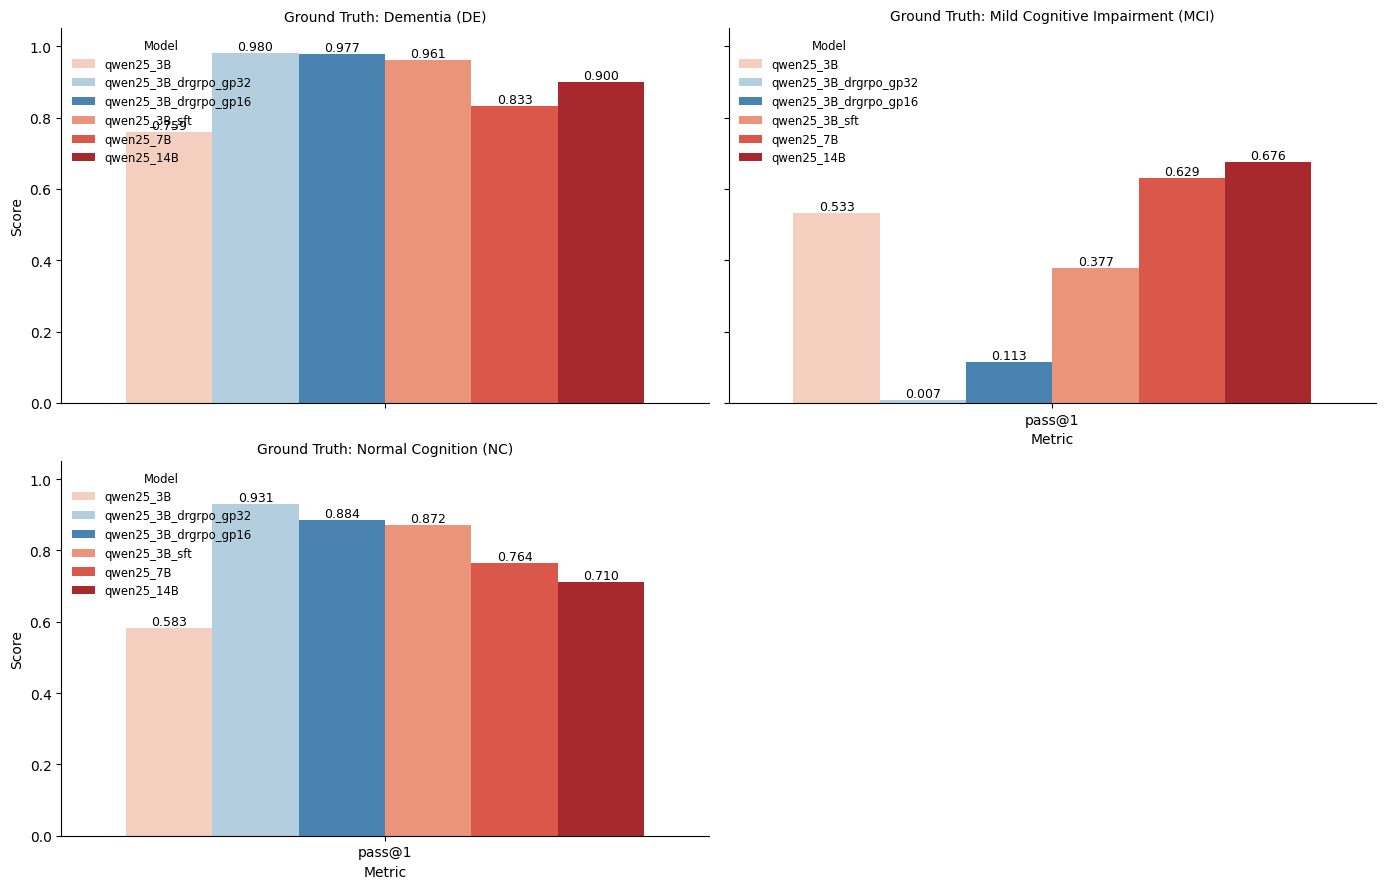

In [106]:
plot_model_comparison_by_gt(df_long, k=1)

In [77]:
import pandas as pd

In [78]:
train = pd.read_csv('/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/training_data_grpo/train_summary_before_np_correction.csv')

In [79]:
train[train['Q_TYPE'] == "Neuropath"]['ground_truth_text'].value_counts()

ground_truth_text
Alzheimer's disease pathology (AD)                                                 633
AD and LBD                                                                         585
Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)    299
None of the above                                                                  165
Lewy body pathology (LBD)                                                           97
AD and FTLD                                                                         92
AD and LBD and FTLD                                                                 71
LBD and FTLD                                                                        58
Name: count, dtype: int64

In [80]:
len(train)

43064

In [81]:
print(train[train['Q_TYPE'] == "Neuropath"].iloc[10]['ground_truth_text'])
print(train[train['Q_TYPE'] == "Neuropath"].iloc[10]['options'])

AD and LBD
A. AD and FTLD
B. LBD and FTLD
C. AD and LBD
D. None of the above
E. AD and LBD and FTLD
F. Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)
G. Alzheimer's disease pathology (AD)
H. Lewy body pathology (LBD)


In [82]:
x = train[train['Q_TYPE'] == "Neuropath"].iloc[10]['options']

In [83]:
def correct_np(row):
    if row['Q_TYPE'] == "Neuropath":
        row['options'] = row['options'].replace("Alzheimer's disease pathology (AD)", "Alzheimer's disease pathology (AD) only").replace("Lewy body pathology (LBD)", "Lewy body pathology (LBD) only").replace("Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)", "Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD) only").replace("AD and LBD and FTLD", "Alzheimer's disease pathology (AD), Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("AD and LBD", "Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)").replace("AD and FTLD", "Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("LBD and FTLD", "Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("None of the above", "No listed option is correct")
        
        row['ground_truth_text'] = row['ground_truth_text'].replace("Alzheimer's disease pathology (AD)", "Alzheimer's disease pathology (AD) only").replace("Lewy body pathology (LBD)", "Lewy body pathology (LBD) only").replace("Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)", "Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD) only").replace("AD and LBD and FTLD", "Alzheimer's disease pathology (AD), Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("AD and LBD", "Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)").replace("AD and FTLD", "Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("LBD and FTLD", "Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("None of the above", "No listed option is correct")
        
    return row

In [84]:
train = train.apply(correct_np, axis=1)

In [85]:
print(train[train['Q_TYPE'] == "Neuropath"].iloc[100]['ground_truth_text'])
print(train[train['Q_TYPE'] == "Neuropath"].iloc[100]['ground_truth'])
print(train[train['Q_TYPE'] == "Neuropath"].iloc[100]['options'])

Alzheimer's disease pathology (AD) only
A
A. Alzheimer's disease pathology (AD) only
B. Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD) only
C. Lewy body pathology (LBD) only
D. Alzheimer's disease pathology (AD), Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)
E. Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)
F. Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)
G. Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)
H. No listed option is correct


In [86]:
train[train['Q_TYPE'] == "Neuropath"]['ground_truth_text'].value_counts()

ground_truth_text
Alzheimer's disease pathology (AD) only                                                                                                              633
Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)                                                                                     585
Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD) only                                                                 299
No listed option is correct                                                                                                                          165
Lewy body pathology (LBD) only                                                                                                                        97
Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)                                92
Alzheimer's disease pathology (AD), Lewy body pathology (LBD) an

In [87]:
train.to_csv('/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/training_data_grpo/train_summary.csv', index=False)

In [88]:
train[train['Q_TYPE'] == "Neuropath"].iloc[10]['options'] == x.replace("Alzheimer's disease pathology (AD)", "Alzheimer's disease pathology (AD) only").replace("Lewy body pathology (LBD)", "Lewy body pathology (LBD) only").replace("Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)", "Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD) only").replace("AD and LBD and FTLD", "Alzheimer's disease pathology (AD), Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("AD and LBD", "Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)").replace("AD and FTLD", "Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("LBD and FTLD", "Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)").replace("None of the above", "No listed option is correct")

True